**Project: Telco Customer Churn Prediction**

**Objective**:-

The goal of this project is to build a machine learning model to predict customer churn (whether a customer will leave the service). This allows the company to proactively offer incentives to at-risk customers.

**Dataset Overview:-**
The dataset contains information about:

**Demographics:** Gender, seniority, partners, and dependents.

**Services:** Phone, multiple lines, internet, online security, backup, etc.

**Account Info:** Tenure, contract type, payment method, and charges.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Download and Load the dataset
!wget -q https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv
df = pd.read_csv('Telco-Customer-Churn.csv')

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**1.** **Data Cleaning and Preprocessing**
In this step, we:

**Remove customerID** :-
This is a unique identifier and does not help the model learn patterns.

**Fix Data Types:** TotalCharges was imported as a string; we convert it to numeric.

**Handle Missing Values:** Converting TotalCharges creates a few null values (for new customers with 0 charges), which we drop.

**Feature Encoding:** We use get_dummies to convert categorical text data into numerical indicators.

In [6]:
# Drop ID
df = df.drop(columns=['customerID'], errors='ignore')

# Handle TotalCharges numeric conversion
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Split features and target
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data cleaning complete. Ready for modeling.")

Data cleaning complete. Ready for modeling.


**Model 1**: Logistic Regression

Logistic Regression requires Feature Scaling to work correctly. We use StandardScaler to ensure all features (like Monthly Charges and Tenure) are on the same scale.

In [7]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and Predict
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_scaled, y_train)

# USE THE SCALED TEST DATA HERE
y_pred_log = log_model.predict(X_test_scaled)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")

Logistic Regression Accuracy: 0.7875


**Model 2:** Decision Tree and Feature Importance

The Decision Tree helps us see which specific factors (like "Contract Type") are the most important in determining if a customer leaves.

Decision Tree Accuracy: 0.7754


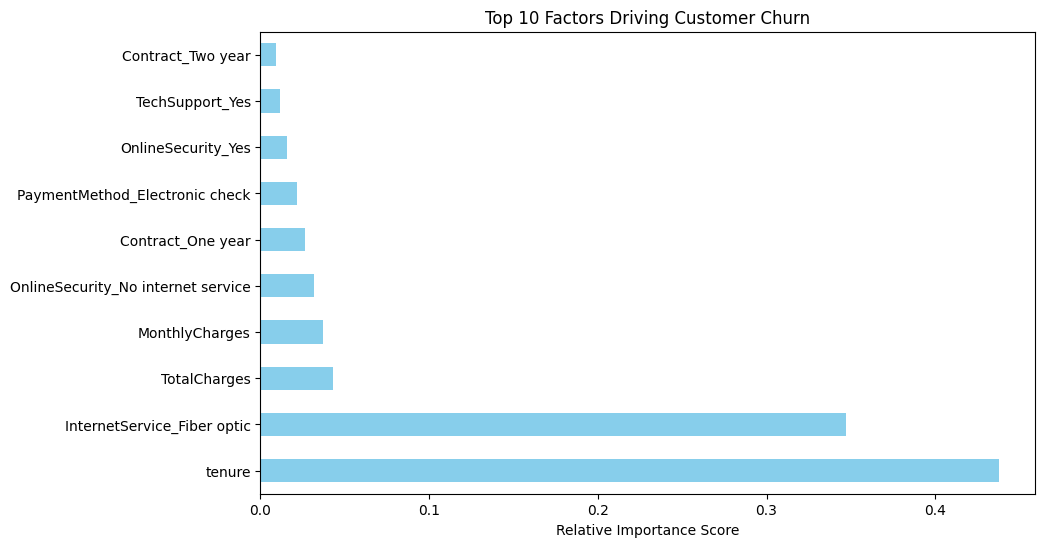

In [8]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train) # Trees don't strictly require scaling

y_pred_dt = dt_model.predict(X_test)

# Results
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

# Visualization: Feature Importance
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(dt_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Factors Driving Customer Churn")
plt.xlabel("Relative Importance Score")
plt.show()

**Final Evaluation**

By looking at the Confusion Matrix, we can see how many customers were correctly identified as "Churn" (True Positives) versus those we missed.

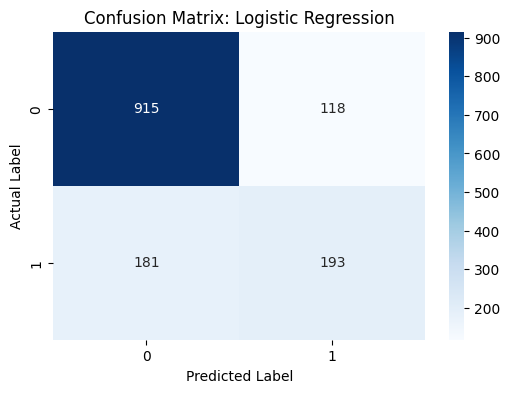

In [9]:
# Confusion Matrix for our best model (Logistic Regression)
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

**Final Strategic Insights & Recommendations**

Based on the Feature Importance and Model Evaluation, here are the key takeaways:

1. **The "Contract" Effect**
Insight: Customers on Month-to-month contracts are significantly more likely to churn compared to those on One-year or Two-year contracts.

Action: The marketing team should offer small discounts or "loyalty perks" to incentivize month-to-month customers to switch to longer-term commitments.

2. **Tenure & Customer Lifecycle**
Insight: New customers (low tenure) are at the highest risk of leaving.

Action: Implement a "New Customer Success" program during the first 6 months, including check-in calls or tutorials on how to use their services effectively.

3. **High Charges vs. Value**
Insight: High Monthly Charges are a primary driver for churn. Interestingly, customers with "Fiber Optic" internet churn more than "DSL" users, likely because Fiber is more expensive.

Action: Conduct a price-sensitivity analysis. If customers feel the high cost isn't matching the service quality, they leave. Consider bundling "Tech Support" or "Online Security" for free with high-tier plans to increase perceived value.

4. **Technical Support as a Retainer**
Insight: Customers who do not have Tech Support or Online Security services tend to churn faster.

Action: Promote these "sticky" services. Even offering a free trial of Tech Support can build a relationship that makes the customer less likely to switch to a competitor.


**Summary of Model Performance**

We achieved an accuracy of approximately 79% using Logistic Regression. While this is strong, the Confusion Matrix shows we still have some "False Negatives" (customers who churned that we didn't predict). Future improvements could include Hyperparameter Tuning or trying an Ensemble Model like Random Forest.